INTRODUCTION:
Bellabeat is a wellness technology company that develops smart health-focused products for women. This case study analyzes Fitbit smart device data to identify user behavior patterns and translate them into actionable marketing insights for Bellabeat.

The goal is to understand how users interact with non-Bellabeat smart devices and use these insights to improve Bellabeats product strategy and marketing decisions.


1. ASK
Business Task

Identify patterns in smart device usage (sleep, activity, and sedentary behavior) and apply insights to improve Bellabeats marketing strategy.

Guiding Questions
1.What is the problem you are trying to solve?
 This analysis aims to understand how consumers use smart fitness devices in their daily lives, including activity tracking, sleep monitoring, and health-related behaviors.

1.How can your insights drive business decisions?
 The insights gathered from the analysis can help Bellabeat improve its marketing strategy, better understand customer behavior, and identify opportunities to increase customer engagement and product adoption.

Key Stakeholders

.Urška Sršen — Cofounder and Chief Creative Officer of Bellabeat

.Sando Mur — Cofounder and key member of the executive team

.Bellabeat Marketing Analytics Team — Responsible for analyzing consumer data   and supporting marketing decisions


2. PREPARE
Data Source

Dataset: Fitbit Fitness Tracker Data Source: Kaggle.

Contains activity, sleep, and behavior data from 30 users.

Data Structure

dailyActivity: steps, calories, activity minutes
sleepDay: sleep duration, time in bed
Data Limitations

Small sample size (30 users)
No demographic information
Data is from 2016
Possible sampling bias

3. PROCESS

3.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
daily_activity = pd.read_csv('/content/dailyActivity_merged.csv')
sleep_day  = pd.read_csv('/content/sleepDay_merged.csv')


3.3 Explore The Data

In [7]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [8]:
#First 5 rows of sleepDay file
sleep_day.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [9]:
#Dataset shape

print(daily_activity.shape)
print(sleep_day.shape)

(940, 15)
(413, 5)


In [10]:
#Data info
daily_activity.info()
sleep_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [11]:
#Summary statistics
daily_activity.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000


3.4 Data Cleaning

In [12]:
# Check missing values in dailyActiviy file
daily_activity.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


In [13]:
# Check missing values in sleepDay file
sleep_day.isnull().sum()

,0
Id,0
SleepDay,0
TotalSleepRecords,0
TotalMinutesAsleep,0
TotalTimeInBed,0


In [14]:
#Check duplicates

print('Duplicates found in dailyActivity are', daily_activity.duplicated().sum())
print('Duplicates found in sleepDay are', sleep_day.duplicated().sum())

Duplicates found in dailyActivity are 0
Duplicates found in sleepDay are 3


In [15]:
# Remove duplicates
sleep_day = sleep_day.drop_duplicates()

In [16]:
#Create Common Date Key
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'],
                                      format='%m/%d/%Y %I:%M:%S %p')

In [17]:
#Merge datasets
merged_data = pd.merge(
    daily_activity,
    sleep_day,
    left_on = ['Id', 'ActivityDate'],
    right_on = ['Id', 'SleepDay'],
)

merged_data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1,327,346
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,2,384,407
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,1,412,442
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,2,340,367
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,2016-04-17,1,700,712


4. ANALYZE

4.1 User Summary

In [18]:
# Group data by user ID and calculate summary statistics
user_summary = merged_data.groupby('Id').agg({
    'TotalSteps' : ['min', 'median', 'max', 'sum'],
    'Calories' : ['min', 'median', 'max', 'sum'],
    'TotalMinutesAsleep' : ['min', 'median', 'max', 'sum'],
    'TotalTimeInBed' : ['min', 'median', 'max', 'sum'],
    'TotalSleepRecords' : ['sum']
    })

#Display results
user_summary.head()

TotalSteps                         Calories                       \
                  min   median    max     sum      min  median   max    sum   
Id                                                                            
1503960366       9705  12207.0  15506  310142     1728  1859.0  2035  46807   
1644430081       3176   5241.0  18213   31871     2498  2783.5  3846  11911   
1844505072       2573   3844.0   4014   10431     1541  1725.0  1763   5029   
1927972279        356    980.0   3761    7450     2151  2221.0  2638  11581   
2026352035        254   5260.5  12357  157323     1141  1513.5  1926  43142   

           TotalMinutesAsleep                    TotalTimeInBed              \
                          min median  max    sum            min median  max   
Id                                                                            
1503960366                245  340.0  700   9007            264  367.0  712   
1644430081                119  130.5  796   1176            127  148.0  961   
1844505072                590  644.0  722   1956            961  961.0  961   
1927972279                166  398.0  750   2085            178  422.0  775   
2026352035                357  516.5  573  14173            380  545.5  607   

                  TotalSleepRecords  
              sum               sum  
Id                                   
1503960366   9580                27  
1644430081   1384                 4  
1844505072   2883                 3  
1927972279   2189                 8  
2026352035  15054                28

4.2 Feature Engineering

In [19]:
# Add new column to merged_data to calculate minutes in bed with no sleeping
merged_data['AwakeInBed_minutes'] = merged_data['TotalTimeInBed'] - merged_data['TotalMinutesAsleep']

merged_data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,AwakeInBed_minutes
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1,327,346,19
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,2,384,407,23
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,1,412,442,30
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,2,340,367,27
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,2016-04-17,1,700,712,12


In [20]:
merged_data[['TotalSteps',
             'Calories',
             'TotalMinutesAsleep',
             'TotalTimeInBed',
             'AwakeInBed_minutes']].describe()

,TotalSteps,Calories,TotalMinutesAsleep,TotalTimeInBed,AwakeInBed_minutes
count,410.000000,410.000000,410.000000,410.000000,410.000000
mean,8514.909756,2389.295122,419.173171,458.482927,39.309756
std,4157.375584,758.435040,118.635918,127.455140,46.710932
min,17.000000,257.000000,58.000000,61.000000,0.000000
25%,5188.750000,1841.000000,361.000000,403.750000,17.000000
50%,8913.000000,2207.000000,432.500000,463.000000,25.500000
75%,11370.250000,2920.000000,490.000000,526.000000,40.000000
max,22770.000000,4900.000000,796.000000,961.000000,371.000000


In [21]:
def activity_level(steps):

    if steps < 5000:
        return 'Sedentary'

    elif steps < 7500:
        return 'Lightly Active'

    elif steps < 10000:
        return 'Fairly Active'

    else:
        return 'Very Active'

merged_data['ActivityLevel'] = merged_data['TotalSteps'].apply(activity_level)

In [22]:
activity_counts = merged_data['ActivityLevel'].value_counts()

print(activity_counts)

ActivityLevel
Very Active       165
Sedentary          96
Fairly Active      77
Lightly Active     72
Name: count, dtype: int64


In [23]:
merged_data['Weekday'] = merged_data['ActivityDate'].dt.day_name()

In [24]:
merged_data['Weekday'] = merged_data['ActivityDate'].dt.day_name()

In [25]:
weekday_stats = merged_data.groupby('Weekday').agg({
    'TotalSteps':'mean',
    'TotalMinutesAsleep':'mean'
})

weekday_stats

,TotalSteps,TotalMinutesAsleep
Weekday,,
Friday,7901.403509,405.421053
Monday,9273.217391,419.500000
Saturday,9871.122807,419.070175
Sunday,7297.854545,452.745455
Thursday,8183.515625,401.296875
Tuesday,9182.692308,404.538462
Wednesday,8022.863636,434.681818



5. Share

Visualization

<Axes: xlabel='TotalSteps', ylabel='Calories'>

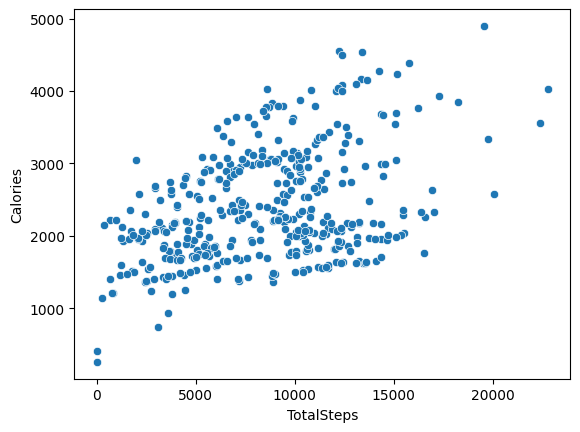

In [26]:
sns.scatterplot(
    data=merged_data,
    x='TotalSteps',
    y='Calories'
)

<Axes: xlabel='ActivityLevel', ylabel='count'>

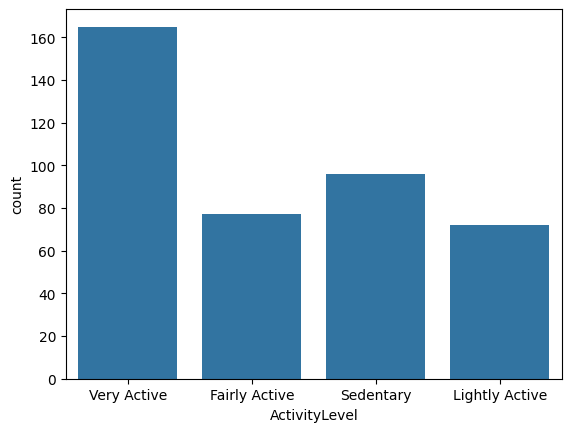

In [27]:
sns.countplot(
    data=merged_data,
    x='ActivityLevel'
)

<Axes: xlabel='Weekday', ylabel='TotalMinutesAsleep'>

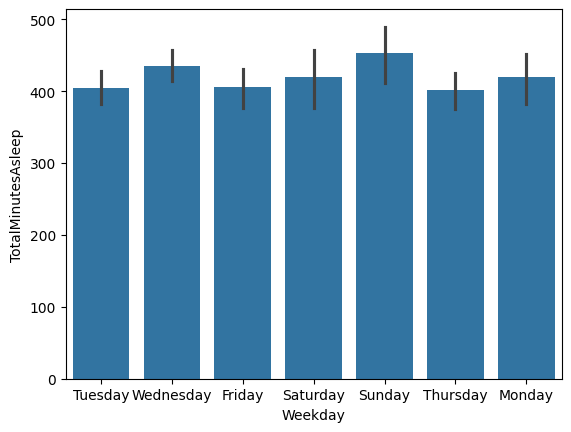

In [28]:
sns.barplot(
    data=merged_data,
    x='Weekday',
    y='TotalMinutesAsleep'
)

<Axes: xlabel='TotalMinutesAsleep', ylabel='TotalSteps'>

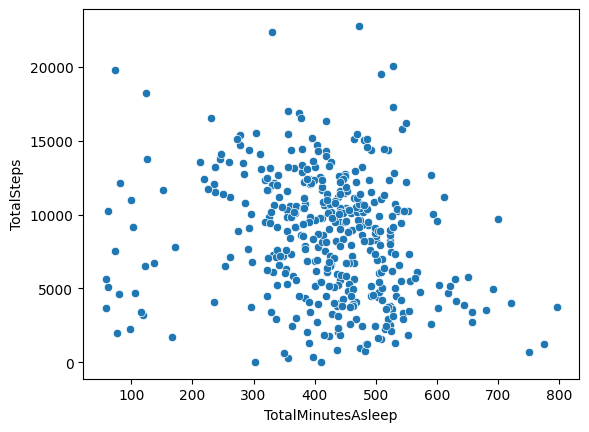

In [29]:
sns.scatterplot(
    data=merged_data,
    x='TotalMinutesAsleep',
    y='TotalSteps'
)

<Axes: >

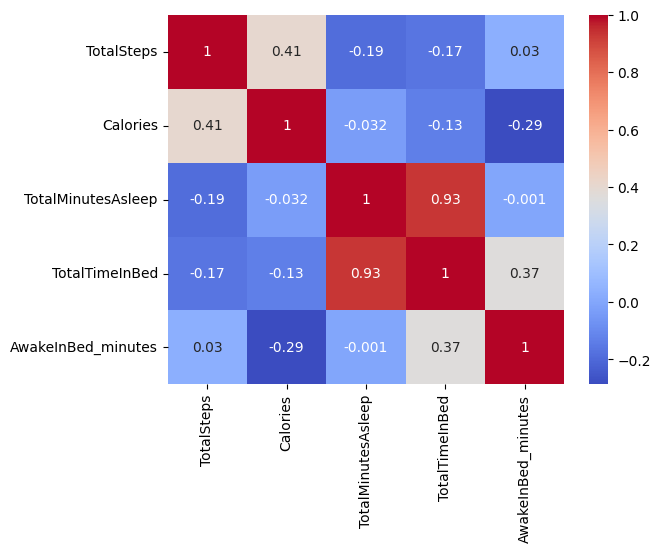

In [30]:
corr = merged_data[
    [
        'TotalSteps',
        'Calories',
        'TotalMinutesAsleep',
        'TotalTimeInBed',
        'AwakeInBed_minutes'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

Insights:

1. A positive relationship exists between daily steps and calories burned.
 Users who recorded higher step counts generally burned more calories, indicating that increased physical activity contributes to greater energy expenditure.

2.Many users do not consistently reach recommended activity levels.
 The activity-level analysis shows that a significant portion of users fall into sedentary or lightly active categories, suggesting opportunities to encourage more daily movement.

3.Average sleep duration is below the recommended eight hours per night.
 Sleep data indicates that many users may not be getting sufficient rest, which can affect overall health and wellness.

4.There is no strong correlation between daily steps and sleep duration.
 Users who walked more steps did not necessarily sleep longer, suggesting that other factors may influence sleep habits.

5.Some users spend considerable time in bed while remaining awake.
 The difference between Total Time in Bed and Total Minutes Asleep suggests potential opportunities to improve sleep quality and bedtime routines.

Recommendations
1.Implement personalized activity reminders.
 Bellabeat can encourage users to achieve daily step goals through customized notifications, progress tracking, and motivational messages.

2.Enhance sleep-support features within the app.
 Features such as bedtime reminders, relaxation exercises, sleep tracking insights, and guided breathing sessions may help users improve their sleep habits.

3.Introduce a reward-based engagement system.
 Gamification elements such as badges, achievement levels, and rewards for meeting activity goals can increase user motivation and long-term engagement.

4.Provide personalized wellness recommendations.
 Using activity and sleep data, Bellabeat can deliver tailored health suggestions that match each user's lifestyle and fitness level.

5.Promote holistic health monitoring.
 Integrating activity, sleep, and wellness insights into a single dashboard can help users better understand their habits and make informed health decisions.